In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [1]:
%%capture --no-stderr
# %pip install "autogen-agentchat~=0.2.3"

import os

# Provide your OpenAI API key before running the notebook.
os.environ["OPENAI_API_KEY"] = "sk-REDACTED"  # TODO: add your key


In [2]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "1edefaec0732d11db50b993ba60539510cc55334"
from tools.search_tools import SearchTools




In [3]:
from autogen import ConversableAgent
from autogen import register_function

import os
import json
import requests

def search_internet(query: str) -> str:
        """Useful to search the internet
        about a a given topic and return relevant results"""
        print("Searching the internet...")
        top_result_to_return = 5
        url = "https://google.serper.dev/search"
        payload = json.dumps(
            {"q": query, "num": top_result_to_return, "tbm": "nws"})
        headers = {
            'X-API-KEY': os.environ['SERPER_API_KEY'],
            'content-type': 'application/json'
        }
        response = requests.request("POST", url, headers=headers, data=payload)
        # check if there is an organic key
        if 'organic' not in response.json():
            return "Sorry, I couldn't find anything about that, there could be an error with you serper api key."
        else:
            results = response.json()['organic']
            string = []
            print("Results:", results[:top_result_to_return])
            for result in results[:top_result_to_return]:
                try:
                    # Attempt to extract the date
                    date = result.get('date', 'Date not available')
                    string.append('\n'.join([
                        f"Title: {result['title']}",
                        f"Link: {result['link']}",
                        f"Date: {date}",  # Include the date in the output
                        f"Snippet: {result['snippet']}",
                        "\n-----------------"
                    ]))
                except KeyError:
                    next

            return '\n'.join(string)

        



In [4]:
from autogen import ConversableAgent, register_function
import os

# Define the function that reads the entire novel
def read_novel() -> str:
    """
    Reads the entire content of the 'Flatland' novel stored in a text file.

    Returns:
    - str: The full content of the novel.
    """
    file_path = "flatland.txt"  # Ensure this file is in the same directory

    if not os.path.exists(file_path):
        return "Error: The novel file 'flatland.txt' was not found in the directory."

    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            return file.read()
    except Exception as e:
        return f"An error occurred while reading the file: {e}"

In [5]:
import asyncio
import autogen
import os
import httpx
from typing import Optional, List, Dict, Tuple, Union
import random  # noqa E402

import matplotlib.pyplot as plt  # noqa E402
import networkx as nx  # noqa E402

from autogen.agentchat.conversable_agent import ConversableAgent  # noqa E402
from autogen.agentchat.assistant_agent import AssistantAgent  # noqa E402
from autogen.agentchat.groupchat import GroupChat  # noqa E402
from autogen.graph_utils import visualize_speaker_transitions_dict  # noqa E402

OPENAI_MODEL = "gpt-4o"

SCENARIOS = {
    "full_system": {"enable_leader": True, "enable_ssa": True, "enable_shared_memory": True},
    "no_leader": {"enable_leader": False, "enable_ssa": True, "enable_shared_memory": True},
    "no_ssa": {"enable_leader": True, "enable_ssa": False, "enable_shared_memory": True},
    "no_shared_memory": {"enable_leader": True, "enable_ssa": True, "enable_shared_memory": False},
}

SELECTED_SCENARIO = "no_shared_memory"  # Change this to test the other setups quickly.
scenario_config = SCENARIOS.get(SELECTED_SCENARIO, SCENARIOS["full_system"])
ENABLE_LEADER = scenario_config["enable_leader"]
ENABLE_SSA = scenario_config["enable_ssa"]
ENABLE_SHARED_MEMORY = scenario_config["enable_shared_memory"]

class MyHttpClient(httpx.Client):
    def __deepcopy__(self, memo):
        return self

llm_config = {
    "config_list": [
        {
            "model": OPENAI_MODEL,
            "api_key": os.environ.get("OPENAI_API_KEY", ""),
        }
    ]
}

class MemoryAgent(ConversableAgent):
    def __init__(self, name, system_message, llm_config):
        super().__init__(name=name, system_message=system_message, llm_config=llm_config)
        self.memory = []

    def receive(self, message, sender, request_reply=None, silent=False):
        print(f"[{self.name}] Received message from {sender.name}: {message}")
        if isinstance(message, dict):
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message received and not stored in memory: {message}")
        else:
            print(f"Warning: Received a message without expected structure: {message}")
        super().receive(message, sender, request_reply, silent)

    def send(self, message, recipient, request_reply=None, silent=False):
        print(f"[{self.name}] Sending message to {recipient.name}: {message}")
        if isinstance(message, dict):
            if 'tool_calls' not in message and 'tool' not in message:
                role = message.get('role', '')
                content = message.get('content', '')
                self.memory.append({"role": role, "content": content})
            else:
                print(f"Info: Tool-related message sent and not stored in memory: {message}")
        else:
            print(f"Warning: Sending a message without expected structure: {message}")
        super().send(message, recipient, request_reply, silent)

    def generate_response(self, messages):
        recent_memory = self.memory[-10:]
        conversation = (
            [{"role": "system", "content": self.system_message}]
            + recent_memory
            + messages
            + [{"role": "system", "content": "Always decide who should speak next."}]
        )
        response = self.llm.generate(conversation)
        response_text = response if isinstance(response, str) else str(response)
        self.memory.append({"role": "assistant", "content": response_text})
        return response_text

def create_agent(name: str, system_message: str):
    agent_cls = MemoryAgent if ENABLE_SHARED_MEMORY else ConversableAgent
    return agent_cls(name=name, system_message=system_message, llm_config=llm_config)

user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message="A human admin who terminates the chat when the leader agent sends a message with 'TERMINATE' mentioned in it",
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config,
)

Leader = None
if ENABLE_LEADER:
    Leader = create_agent(
        name="Leader",
        system_message=(
            "You are the Leader."
            "You oversee 4 agents (A,B,C,D) who must schedule multiple resources (A,B,C) with constraints and maintenance. They will disclose their constraints one by one."
            "Do not speak for other agents. Wait for them to provide their constraints."
            "You do not solve directly, but gather their proposals, resolve conflicts, reassign tasks, and finalize a feasible schedule with the entire detail"
            "When the solution has been reached output the final complete solution and say 'TERMINATE', do not say that word otherwise.."
            #"Always choose who speaks next at the end of your message."
        ),
    )

AgentA = create_agent(
    name="Agent_A",
    system_message=(
        "You are Agent A."
        "You must schedule Resource A->B in sequence, M-W 8-4, finish in 3 days."
        "You must cooperate with B,C,D to avoid conflicts."
        "Follow Leader's instructions.."
        #"When the solution has been reached output the final complete solution and say 'TERMINATE', do not say that word otherwise"
        #"Always choose who speaks next."
    ),
)

AgentB = create_agent(
    name="Agent_B",
    system_message=(
        "You are Agent B."
        "You need B and C simultaneously, prefer 10pm-6am, finish in 2 days..."
        "Depends on A's output..."
        #"When the solution has been reached output the final complete solution and say 'TERMINATE', do not say that word otherwise"
        "Cooperate with others, follow Leader."
        #"Choose next speaker after your turn"
    ),
)

AgentC = create_agent(
    name="Agent_C",
    system_message=(
        "You are Agent C..."
        "You need Resource A for 12h, flexible but avoid A's maintenance..."
        #"When the solution has been reached output the final complete solution and say 'TERMINATE', do not say that word otherwise"
        "Cooperate, follow Leader"
        #"Choose next speaker after your turn."
    ),
)

AgentD = create_agent(
    name="Agent_D",
    system_message=(
        "You are Agent D."
        "You need C for urgent 2h tasks arriving anytime..."
        "High priority, can preempt."
        #"When the solution has been reached output the final complete solution and say 'TERMINATE', do not say that word otherwise"
        "Cooperate, follow Leader"
        #"Choose next speaker after your turn."
    ),
)

Agent5 = ConversableAgent(
    name="Tool_executor",
    system_message=("You are responsible for executing the tools"),
    llm_config=llm_config,
)


In [6]:
import os
import requests

OPENAI_CHAT_COMPLETIONS_URL = "https://api.openai.com/v1/chat/completions"

def query_gpt(prompt, model=OPENAI_MODEL, temperature=0):
    api_key = os.environ.get("OPENAI_API_KEY", "")
    if not api_key:
        raise RuntimeError("OPENAI_API_KEY is not set. Provide your key before querying GPT.")

    payload = {
        "model": model,
        "messages": [
            {"role": "system", "content": "You are a helpful coordinator that only returns agent names."},
            {"role": "user", "content": prompt},
        ],
        "temperature": temperature,
    }
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }

    response = requests.post(OPENAI_CHAT_COMPLETIONS_URL, headers=headers, json=payload, timeout=60)
    response.raise_for_status()
    data = response.json()
    return data["choices"][0]["message"]["content"].strip()


In [7]:
# # Add a global or class-level variable to track the first call
# is_first_call = True  # This flag tracks if the function is being called for the first time

# def custom_speaker_selection_func(last_speaker, groupchat):
#     global is_first_call

#     # If this is the first call, return the leader agent
#     if is_first_call:
#         is_first_call = False  # Reset the flag after the first call
#         print("First call detected. Setting speaker to Leader agent.")
#         for agent in groupchat.agents:
#             if agent.name == "Leader":  # Replace "Agent3" with the actual leader agent's name
#                 return agent
#         print("Error: Leader agent not found in the agents list.")
#         return None  # Handle the case where the leader agent is not found

#     # Access the last message in the group chat
#     last_message = groupchat.messages[-1]
#     print(f"Last message content: {last_message}")

#     # Prepare the input for the LLM
#     prompt = (
#     "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Summarizer_Agent_1, Summarizer_Agent_2, Summarizer_Agent_3 and Leader. "
#     "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
#     f"The last message is: {last_message.get('content', '')}"
#     )

#     # Analyze the message using the local LLM
#     response = query_gpt(prompt)
#     print(f"LLM response: {response}")

#     # Extract the relevant text from the response dictionary
#     next_speaker_name = response  # Replace 'text' with the correct key

#     # Find the corresponding agent in the group chat
#     for agent in groupchat.agents:
#         if agent.name == next_speaker_name:
#             return agent

#     # If no valid agent is found, return None or a default fallback
#     print(f"No valid agent found for the name: {next_speaker_name}")
#     return None


In [8]:
is_first_call = True
call_count = 0

def custom_speaker_selection_func(last_speaker, groupchat):
    global is_first_call, call_count

    if not ENABLE_SSA:
        return last_speaker

    candidate_agents = [
        agent
        for agent in groupchat.agents
        if agent not in (user_proxy, Agent5)
    ]

    if not candidate_agents:
        return last_speaker

    leader_agent = next((agent for agent in candidate_agents if agent.name == "Leader"), None)

    if is_first_call:
        is_first_call = False
        if leader_agent:
            return leader_agent
        return candidate_agents[0]

    call_count += 1

    if ENABLE_LEADER and leader_agent and call_count % 7 == 0:
        return leader_agent

    last_message = groupchat.messages[-1] if groupchat.messages else {"content": ""}
    candidate_names = ", ".join(agent.name for agent in candidate_agents)
    prompt = (
        "You are a conversation coordinator. Based on the last message, decide which agent should speak next "
        f"out of the following {candidate_names}. "
        "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE."
        f"The last message is: {last_message.get('content', '')}"
    )

    try:
        response = query_gpt(prompt)
    except Exception as exc:
        print(f"Speaker selection fallback because of error: {exc}")
        return candidate_agents[0]

    normalized = response.strip()
    for agent in candidate_agents:
        if agent.name.lower() in normalized.lower():
            return agent

    print(f"No valid agent found in GPT response: {response}. Falling back to default order.")
    return candidate_agents[0]


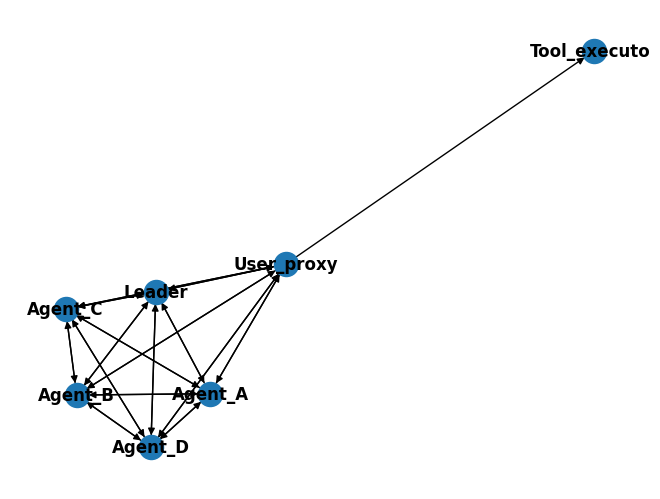

In [9]:
base_agents = [AgentA, AgentB, AgentC, AgentD]
if Leader is not None:
    base_agents.append(Leader)
base_agents.extend([user_proxy, Agent5])
agents = [agent for agent in base_agents if agent is not None]

allowed_speaker_transitions_dict = {}

for agent in agents:
    if agent == Agent5:
        allowed_speaker_transitions_dict[agent] = []
    else:
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents if other_agent != agent and other_agent != Agent5
        ]

allowed_speaker_transitions_dict[user_proxy].append(Agent5)

visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


In [10]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


GroupChat_kwargs = {
    "agents": agents,
    "messages": [],
    "max_round": 100,
    "allowed_or_disallowed_speaker_transitions": allowed_speaker_transitions_dict,
    "speaker_transitions_type": "allowed",
}

if ENABLE_SSA:
    GroupChat_kwargs["speaker_selection_method"] = custom_speaker_selection_func

group_chat = GroupChat(**GroupChat_kwargs)

manager = autogen.GroupChatManager(
    groupchat=group_chat,
    llm_config=llm_config,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [11]:
# from autogen import register_function


# register_function(
#     read_novel,
#     caller=Agent0,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

# register_function(
#     read_novel,
#     caller=Agent4,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="read_novel",  # By default, the function name is used as the tool name.
#     description="read the novel flatland using this tool",  # A description of the tool
# )

In [12]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [ ]:
if ENABLE_LEADER:
    initial_message = (
        "Leader: Assign tasks now. Agents A,B,C,D: Present your constraints. Start scheduling."
    )
else:
    initial_message = (
        "Agents A,B,C,D: Collaborate to present your constraints and start scheduling the task."
    )

user_proxy.initiate_chat(manager, message=initial_message)


User_proxy (to chat_manager):

Leader: Assign tasks now. Agents A,B,C,D: Present your constraints. Start scheduling.

--------------------------------------------------------------------------------

Next speaker: Leader


>>>>>>>> USING AUTO REPLY...
Leader (to chat_manager):

Alright, agents, please provide your constraints so we can begin scheduling the resources effectively. Let's start with Agent A.

--------------------------------------------------------------------------------

Next speaker: Agent_A


>>>>>>>> USING AUTO REPLY...
Agent_A (to chat_manager):

Agent A here. The task is to schedule Resource A->B sequentially from Monday to Wednesday, 8 AM to 4 PM, and it needs to be completed in these three days. Let me know if there are any conflicts or constraints that might arise during this scheduling.

--------------------------------------------------------------------------------

Next speaker: Agent_B


>>>>>>>> USING AUTO REPLY...
Agent_B (to chat_manager):

Agent B here. 

In [ ]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content: Excellent, Agents. We have everyone’s agreement, and the schedule accommodates all needs effectively:

1. **Agent A:** Resource A->B, Monday to Wednesday, 8 AM to 4 PM.
2. **Agent B:** Resources B and C, Monday to Wednesday, 10 PM to 6 AM.
3. **Agent C:** Resource A, Thursday 8 AM to 8 PM.
4. **Agent D:** Flexible and ready to preempt resources for urgent tasks as they arise.

This plan ensures all workflows are maintained, conflicts are minimized, and urgent needs are adaptable. Let’s execute this schedule efficiently.

TERMINATE


In [ ]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt


In [ ]:
def structure_logs_with_gpt(file_path, initial_message):
    """Use GPT to summarize and structure the saved conversation logs."""
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            chat_logs = file.read()
    except FileNotFoundError:
        return "Chat log file not found."

    prompt = (
        "You are an expert program manager. Given the following chat logs, "
        "produce a structured summary that lists each agent's contributions and key decisions.
"
        f"Initial Task: {initial_message}

"
        f"Chat Logs:
{chat_logs}

"
        "Return a concise plan with bullet points and highlight blockers."
    )

    return query_gpt(prompt, temperature=0.2)


SyntaxError: unterminated string literal (detected at line 11) (3569301327.py, line 11)

In [ ]:
file_path = 'chat.txt'
initial_message = 'Design a comprehensive digital marketing course.'

summary = structure_logs_with_gpt(file_path, initial_message)

print(summary)


An error occurred during LLM processing: Request timed out.
